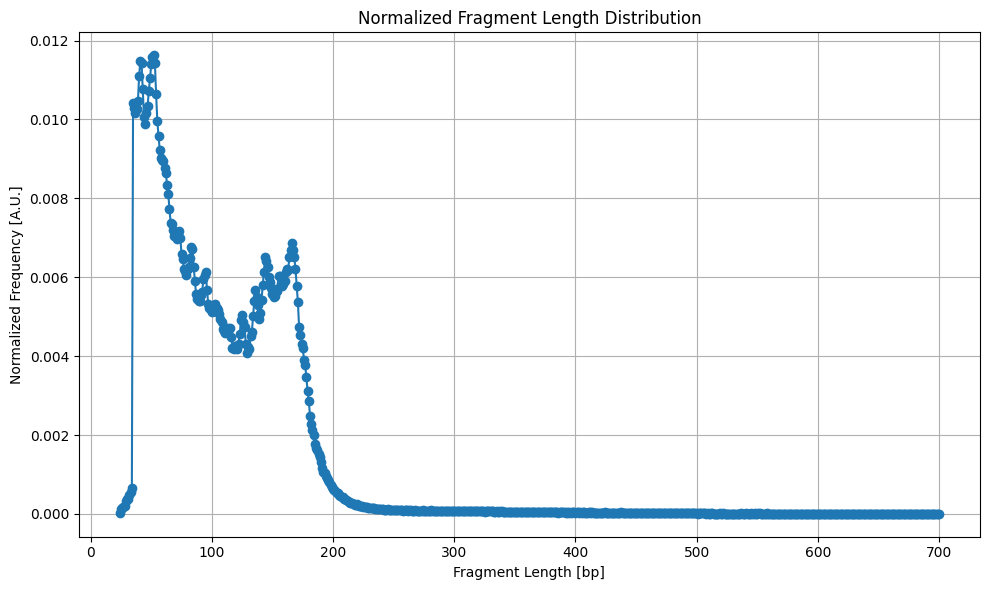

In [2]:
import gzip
import numpy as np
import matplotlib.pyplot as plt

# Load the BED file
fragment_lengths = []

with gzip.open('query.bed.gz', 'rt') as f:
    for line in f:
        if line.strip():  # Skip empty lines
            fields = line.strip().split('\t')
            start = int(fields[1])
            end = int(fields[2])
            fragment_lengths.append(end - start)

# Convert to numpy array
fragment_lengths = np.array(fragment_lengths)

# Count frequencies of each fragment length
unique_lengths, counts = np.unique(fragment_lengths, return_counts=True)

# Normalize the counts
normalized_counts = counts / counts.sum()

# Plot
plt.figure(figsize=(10, 6))
plt.plot(unique_lengths, normalized_counts, marker='o', linestyle='-')
plt.xlabel('Fragment Length [bp]')
plt.ylabel('Normalized Frequency [A.U.]')
plt.title('Normalized Fragment Length Distribution')
plt.grid(True)
plt.tight_layout()
plt.show()


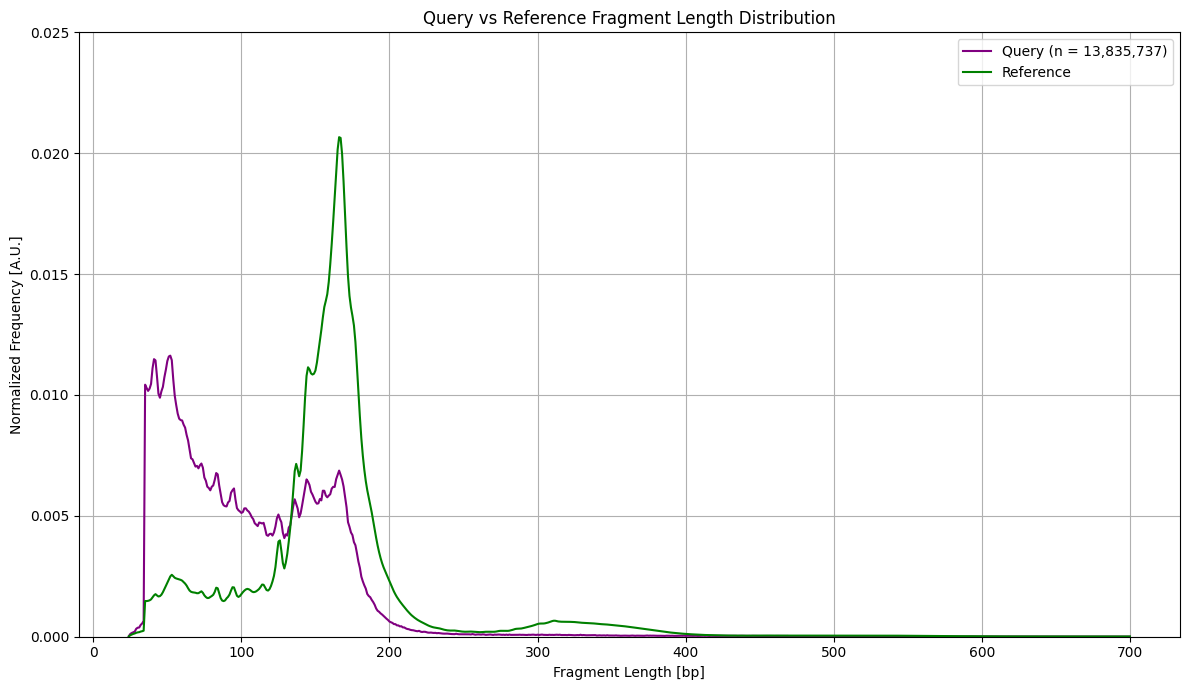

In [3]:
from collections import Counter

# Step 1: Load Reference Histogram
ref_hist = {}
with open("reference.hist", 'r') as f:
    for line in f:
        if line.strip():
            length, freq = line.strip().split()
            ref_hist[int(length)] = float(freq)

# Normalize reference
total_ref = sum(ref_hist.values())
ref_norm = {k: v / total_ref for k, v in ref_hist.items()}

# Step 2: Load Query BED File and Compute Fragment Lengths
query_lengths = []

with gzip.open("query.bed.gz", 'rt') as f:
    for line in f:
        fields = line.strip().split('\t')
        start = int(fields[1])
        end = int(fields[2])
        length = end - start
        query_lengths.append(length)

# Compute query distribution
query_counts = Counter(query_lengths)
total_query = sum(query_counts.values())
query_norm = {k: v / total_query for k, v in query_counts.items()}

# Step 3: Plot
plt.figure(figsize=(12, 7))

# Plot Query
x_query = sorted(query_norm.keys())
y_query = [query_norm[k] for k in x_query]
plt.plot(x_query, y_query, color='purple', label=f"Query (n = {total_query:,})")

# Plot Reference
x_ref = sorted(ref_norm.keys())
y_ref = [ref_norm[k] for k in x_ref]
plt.plot(x_ref, y_ref, color='green', label="Reference")

# Style plot
plt.xlabel("Fragment Length [bp]")
plt.ylabel("Normalized Frequency [A.U.]")
plt.ylim(0, 0.025)
plt.title("Query vs Reference Fragment Length Distribution")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
